<a href="https://colab.research.google.com/github/toche7/AnalyticCases/blob/main/ParalleldataPrepMyEzpaare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import userdata

# Retrieve the API key from Colab Secrets
# Ensure you have a secret named 'MY_EZPAA_KEY' set in Colab secrets
apikey = userdata.get('MY_EZPAA_KEY')

In [3]:
import requests

url = "https://ezpaarse.cbtumu.io/"

headers = {
    "X-API-Key": apikey,
    "Log-Format-ezproxy": '%h %l %u %t "%r" %s %b',
    "Crypted-Fields": "none",
    "Output-Fields": "+id,+pii,+sudoc-ppn,-platform,-identd,-status,-size",
}

log_data = '''
1.2.3.4 - testuser [31/Jul/2026:17:01:01 +0000] "GET https://www.sciencedirect.com/science/article/pii/S0378517325001279 HTTP/1.1" 200 7544
'''.strip()

r = requests.post(
    url,
    headers=headers,
    data=log_data.encode("utf-8"),
    timeout=60
)

print(r.status_code)
print(r.text)

200
datetime;date;login;platform_name;publisher_name;rtype;mime;print_identifier;online_identifier;title_id;doi;publication_title;publication_date;unitid;domain;on_campus;log_id;ezpaarse_version;ezpaarse_date;middlewares_version;middlewares_date;platforms_version;platforms_date;middlewares;id;pii;sudoc-ppn;title;type;subject;geoip-country;geoip-latitude;geoip-longitude;host;url
2026-07-31T17:01:01+00:00;2026-07-31;testuser;Science Direct;Elsevier;ARTICLE;HTML;0378-5173;0378-5173;03785173;10.1016/j.ijpharm.2025.125291;International Journal of Pharmaceutics;2025;S0378517325001279;www.sciencedirect.com;N;88ac51fcc9ff1ef1f541c091e475b43358d0372d;3.12.0;;78f24a4;2026-09-11;bf86a56f;2026-09-23;filter, parser, deduplicator, istex, crossref, sudoc, hal, enhancer, geolocalizer, cut, on-campus-counter, qualifier, anonymizer;;S0378517325001279;;Rubicon siRNA-encapsulated liver-targeting nanoliposome is a promising therapeutic for non-alcoholic fatty liver disease;journal-article;;AU;-33.494;143.2

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
log_file_path = '/content/drive/MyDrive/EZproxyData/ezp_aug01-03_2026.log' # 3 day


try:
    with open(log_file_path, 'r') as f:
        file_log_data = f.read()
    print(f"Successfully read {len(file_log_data)} characters from {log_file_path}")
except FileNotFoundError:
    print(f"Error: The file at {log_file_path} was not found. Please ensure the path is correct and your Google Drive is mounted.")
    file_log_data = None
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    file_log_data = None


Successfully read 100004554 characters from /content/drive/MyDrive/EZproxyData/ezp_aug01-03_2026.log


In [6]:
%%time
if file_log_data:
    url = "https://ezpaarse.cbtumu.io/"

    # Reusing headers from previous successful API call (cell BP71KDCGu-Fe)
    headers = {
        "X-API-Key": apikey, # 'apikey' variable is already defined in the kernel state
        "Log-Format-ezproxy": '%h %l %u %t \"%r\" %s %b',
        "Crypted-Fields": "none",
        "Output-Fields": "+id,+pii,+sudoc-ppn,-platform,-identd,-status,-size",
    }

    # Send only the first 100 lines of the log data to test with a smaller payload
    reduced_log_data = '\n'.join(file_log_data.splitlines()[:100])
    print(f"Sending a reduced log data payload ({len(reduced_log_data)} characters) to ezPAARSE API...")

    r = requests.post(
        url,
        headers=headers,
        data=reduced_log_data.encode("utf-8"),
        timeout=300 # Keep timeout high, but expect faster response for smaller data
    )

    print("Status:", r.status_code)
    print("Response:")
    # Print only the first 1000 characters of the response for brevity
    print(r.text[:1000])
else:
    print("Skipping API call because no log data was read from the file.")


Sending a reduced log data payload (19755 characters) to ezPAARSE API...
Status: 200
Response:
datetime;date;login;platform_name;publisher_name;rtype;mime;print_identifier;online_identifier;title_id;doi;publication_title;publication_date;unitid;domain;on_campus;log_id;ezpaarse_version;ezpaarse_date;middlewares_version;middlewares_date;platforms_version;platforms_date;middlewares;id;pii;sudoc-ppn;title;type;subject;geoip-country;geoip-latitude;geoip-longitude;host;url
2026-07-31T17:00:56+00:00;2026-07-31;Thaneeya.nan;Science Direct;Elsevier;SEARCH;HTML;;;;;;;;www.sciencedirect.com;N;ef177bd25618714f1859882c64993acb094c2e67;3.12.0;;78f24a4;2026-09-11;bf86a56f;2026-09-23;filter, parser, deduplicator, istex, crossref, sudoc, hal, enhancer, geolocalizer, cut, on-campus-counter, qualifier, anonymizer;;;;;;;TH;13.7512;100.5172;49.49.235.38;https://www.sciencedirect.com:443/search?qs=Rubicon%20siRNA-encapsulated%20liver-targeting%20nanoliposome%20is%20a%20promising%20therapeutic%20for%20non-al

In [7]:
import os
import io
import time
import requests
import pandas as pd

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED


# ============================================================
# CONFIG
# ============================================================

INPUT_FILE = '/content/drive/MyDrive/EZproxyData/ezp202608.log'

OUTPUT_FILE = "ezpaarse_output.csv"
CHUNK_OUTPUT_DIR = Path("ezpaarse_chunks")

URL = "https://ezpaarse.cbtumu.io/"
API_KEY = apikey

CHUNK_SIZE = 30000

# --------------------------------------------
# Parallel setting
# --------------------------------------------
MAX_WORKERS = 4

TIMEOUT = 600
MAX_RETRIES = 3
RETRY_WAIT = 5


headers = {
    "X-API-Key": API_KEY,
    "Log-Format-ezproxy": '%h %l %u %t "%r" %s %b',
    "Crypted-Fields": "none",
    "Output-Fields": "+id,+pii,+sudoc-ppn,-platform,-identd,-status,-size",
}


expected_columns = [
    "datetime", "date", "login", "platform_name", "publisher_name",
    "rtype", "mime", "print_identifier", "online_identifier",
    "title_id", "doi", "publication_title", "publication_date",
    "unitid", "domain", "on_campus", "log_id", "ezpaarse_version",
    "ezpaarse_date", "middlewares_version", "middlewares_date",
    "platforms_version", "platforms_date", "middlewares",
    "id", "pii", "sudoc-ppn", "title", "type", "subject",
    "geoip-country", "geoip-latitude", "geoip-longitude",
    "host", "url"
]


CHUNK_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# SEND ONE CHUNK
# ============================================================

def send_chunk(chunk_lines, chunk_no):
    """
    Send one chunk to ezPAARSE.
    Save result to an individual CSV file.

    Return status dictionary.
    """

    output_path = (
        CHUNK_OUTPUT_DIR /
        f"chunk_{chunk_no:05d}.csv"
    )

    # --------------------------------------------------------
    # RESUME
    # Skip if this chunk was already successfully processed
    # --------------------------------------------------------

    if output_path.exists() and output_path.stat().st_size > 0:

        try:
            existing_df = pd.read_csv(
                output_path,
                dtype=str,
                keep_default_na=False
            )

            print(
                f"[SKIP] Chunk {chunk_no:,} | "
                f"{len(existing_df):,} rows already exist"
            )

            return {
                "chunk_no": chunk_no,
                "status": "SKIPPED",
                "input_lines": len(chunk_lines),
                "output_rows": len(existing_df),
                "seconds": 0
            }

        except Exception:
            # File exists but cannot be read:
            # process it again
            pass


    payload = "".join(chunk_lines)

    payload_mb = (
        len(payload.encode("utf-8"))
        / 1024
        / 1024
    )


    # --------------------------------------------------------
    # RETRY LOOP
    # --------------------------------------------------------

    for attempt in range(
        1,
        MAX_RETRIES + 1
    ):

        chunk_start = time.time()

        try:

            print(
                f"[START] Chunk {chunk_no:,} | "
                f"{len(chunk_lines):,} lines | "
                f"{payload_mb:.2f} MB | "
                f"attempt {attempt}/{MAX_RETRIES}"
            )


            response = requests.post(
                URL,
                headers=headers,
                data=payload.encode("utf-8"),
                timeout=TIMEOUT
            )


            # ------------------------------------------------
            # HTTP error
            # ------------------------------------------------

            if response.status_code != 200:

                print(
                    f"[ERROR] Chunk {chunk_no:,} | "
                    f"HTTP {response.status_code} | "
                    f"{response.text[:300].replace(chr(10), ' ')}"
                )

                if attempt < MAX_RETRIES:

                    wait_time = (
                        RETRY_WAIT * attempt
                    )

                    print(
                        f"Retrying chunk "
                        f"{chunk_no:,} in "
                        f"{wait_time}s..."
                    )

                    time.sleep(wait_time)

                continue


            # ------------------------------------------------
            # Empty response
            # ------------------------------------------------

            if not response.text.strip():

                df = pd.DataFrame(
                    columns=expected_columns
                )

            else:

                try:

                    df = pd.read_csv(
                        io.StringIO(
                            response.text
                        ),
                        sep=";",
                        dtype=str,
                        keep_default_na=False
                    )

                except pd.errors.EmptyDataError:

                    df = pd.DataFrame(
                        columns=expected_columns
                    )


            # ------------------------------------------------
            # COLUMN ORDER
            # ------------------------------------------------

            canonical = [
                c
                for c in expected_columns
                if c in df.columns
            ]

            extra = [
                c
                for c in df.columns
                if c not in expected_columns
            ]

            df = df[
                canonical + extra
            ]


            # ------------------------------------------------
            # SAVE CHUNK
            # ------------------------------------------------

            df.to_csv(
                output_path,
                index=False,
                encoding="utf-8"
            )


            elapsed = (
                time.time()
                - chunk_start
            )


            print(
                f"[DONE] Chunk {chunk_no:,} | "
                f"{len(df):,} rows | "
                f"{elapsed:.1f}s"
            )


            return {
                "chunk_no": chunk_no,
                "status": "SUCCESS",
                "input_lines": len(chunk_lines),
                "output_rows": len(df),
                "seconds": elapsed
            }


        except requests.exceptions.Timeout:

            print(
                f"[TIMEOUT] Chunk {chunk_no:,} | "
                f"{TIMEOUT}s"
            )


        except requests.exceptions.RequestException as e:

            print(
                f"[REQUEST ERROR] "
                f"Chunk {chunk_no:,} | "
                f"{e}"
            )


        except Exception as e:

            print(
                f"[ERROR] Chunk {chunk_no:,} | "
                f"{type(e).__name__}: {e}"
            )


        # ----------------------------------------------------
        # RETRY
        # ----------------------------------------------------

        if attempt < MAX_RETRIES:

            wait_time = (
                RETRY_WAIT * attempt
            )

            print(
                f"Retrying chunk "
                f"{chunk_no:,} "
                f"in {wait_time}s..."
            )

            time.sleep(wait_time)


    # --------------------------------------------------------
    # FAILED AFTER ALL RETRIES
    # --------------------------------------------------------

    return {
        "chunk_no": chunk_no,
        "status": "FAILED",
        "input_lines": len(chunk_lines),
        "output_rows": 0,
        "seconds": None
    }


# ============================================================
# CHUNK GENERATOR
# ============================================================

def chunk_generator(
    input_file,
    chunk_size
):

    chunk_lines = []
    chunk_no = 0


    with open(
        input_file,
        "r",
        encoding="utf-8",
        errors="replace"
    ) as f:

        for line in f:

            chunk_lines.append(line)

            if len(chunk_lines) >= chunk_size:

                chunk_no += 1

                yield (
                    chunk_no,
                    chunk_lines
                )

                chunk_lines = []


        # Final partial chunk
        if chunk_lines:

            chunk_no += 1

            yield (
                chunk_no,
                chunk_lines
            )


# ============================================================
# PARALLEL PROCESSING
# ============================================================

def run_parallel():

    start_time = time.time()

    total_input_lines = 0
    total_output_rows = 0

    completed_chunks = 0

    results = []

    failed_chunks = []


    print("=" * 70)

    print(f"Input       : {INPUT_FILE}")
    print(f"Chunk size  : {CHUNK_SIZE:,}")
    print(f"Workers     : {MAX_WORKERS}")

    print("=" * 70)
    print()


    # --------------------------------------------------------
    # We limit the number of jobs "in flight"
    #
    # This is important because we do NOT want Colab to load
    # the entire monthly log into RAM.
    # --------------------------------------------------------

    max_pending_jobs = (
        MAX_WORKERS * 2
    )


    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:


        pending = {}


        for (
            chunk_no,
            chunk_lines
        ) in chunk_generator(
            INPUT_FILE,
            CHUNK_SIZE
        ):


            # ------------------------------------------------
            # Limit pending jobs
            # ------------------------------------------------

            while (
                len(pending)
                >= max_pending_jobs
            ):

                done, _ = wait(
                    pending,
                    return_when=FIRST_COMPLETED
                )


                for future in done:

                    result = future.result()

                    results.append(
                        result
                    )

                    completed_chunks += 1

                    total_input_lines += (
                        result[
                            "input_lines"
                        ]
                    )

                    total_output_rows += (
                        result[
                            "output_rows"
                        ]
                    )


                    if (
                        result["status"]
                        == "FAILED"
                    ):

                        failed_chunks.append(
                            result[
                                "chunk_no"
                            ]
                        )


                    del pending[future]


                    elapsed = (
                        time.time()
                        - start_time
                    )


                    print(
                        f"\nPROGRESS | "
                        f"Chunks: "
                        f"{completed_chunks:,} | "
                        f"Input: "
                        f"{total_input_lines:,} | "
                        f"Output: "
                        f"{total_output_rows:,} | "
                        f"Elapsed: "
                        f"{elapsed / 60:.1f} min"
                    )

                    print("-" * 70)


            # ------------------------------------------------
            # Submit job
            # ------------------------------------------------

            future = executor.submit(
                send_chunk,
                chunk_lines,
                chunk_no
            )

            pending[future] = (
                chunk_no
            )


        # ----------------------------------------------------
        # Finish remaining jobs
        # ----------------------------------------------------

        while pending:

            done, _ = wait(
                pending,
                return_when=FIRST_COMPLETED
            )


            for future in done:

                result = future.result()

                results.append(
                    result
                )

                completed_chunks += 1

                total_input_lines += (
                    result[
                        "input_lines"
                    ]
                )

                total_output_rows += (
                    result[
                        "output_rows"
                    ]
                )


                if (
                    result["status"]
                    == "FAILED"
                ):

                    failed_chunks.append(
                        result[
                            "chunk_no"
                        ]
                    )


                del pending[future]


                elapsed = (
                    time.time()
                    - start_time
                )


                print(
                    f"\nPROGRESS | "
                    f"Chunks: "
                    f"{completed_chunks:,} | "
                    f"Input: "
                    f"{total_input_lines:,} | "
                    f"Output: "
                    f"{total_output_rows:,} | "
                    f"Elapsed: "
                    f"{elapsed / 60:.1f} min"
                )

                print("-" * 70)


    elapsed = (
        time.time()
        - start_time
    )


    return (
        results,
        failed_chunks,
        total_input_lines,
        total_output_rows,
        elapsed
    )


# ============================================================
# MERGE RESULT FILES
# ============================================================

def merge_chunks(
    output_file
):

    chunk_files = sorted(
        CHUNK_OUTPUT_DIR.glob(
            "chunk_*.csv"
        )
    )


    if not chunk_files:

        print(
            "No chunk output files."
        )

        return 0


    # Remove old merged file
    if os.path.exists(
        output_file
    ):

        os.remove(
            output_file
        )


    total_rows = 0

    first_file = True


    print()
    print(
        f"Merging "
        f"{len(chunk_files):,} "
        f"chunk files..."
    )


    for file in chunk_files:

        try:

            df = pd.read_csv(
                file,
                dtype=str,
                keep_default_na=False,
                low_memory=False
            )


            if df.empty:
                continue


            df.to_csv(
                output_file,
                mode="a",
                index=False,
                header=first_file,
                encoding="utf-8"
            )


            first_file = False

            total_rows += len(df)


        except Exception as e:

            print(
                f"[MERGE ERROR] "
                f"{file.name}: {e}"
            )


    print(
        f"Merged rows: "
        f"{total_rows:,}"
    )


    return total_rows


# ============================================================
# RUN
# ============================================================

pipeline_start = time.time()


(
    results,
    failed_chunks,
    total_input_lines,
    total_output_rows,
    processing_time
) = run_parallel()


# ============================================================
# PROCESSING SUMMARY
# ============================================================

results_df = pd.DataFrame(
    results
).sort_values(
    "chunk_no"
)


display(
    results_df
)


# ============================================================
# MERGE
# ============================================================

merged_rows = merge_chunks(
    OUTPUT_FILE
)


# ============================================================
# FINAL SUMMARY
# ============================================================

pipeline_elapsed = (
    time.time()
    - pipeline_start
)


print()
print("=" * 70)

print("FINISHED")

print("=" * 70)

print(
    f"Input lines   : "
    f"{total_input_lines:,}"
)

print(
    f"Output rows   : "
    f"{total_output_rows:,}"
)

print(
    f"Merged rows   : "
    f"{merged_rows:,}"
)

print(
    f"Workers       : "
    f"{MAX_WORKERS}"
)

print(
    f"Chunk size    : "
    f"{CHUNK_SIZE:,}"
)

print(
    f"Process time  : "
    f"{processing_time / 60:.2f} min"
)

print(
    f"Total time    : "
    f"{pipeline_elapsed / 60:.2f} min"
)


if failed_chunks:

    print(
        f"Failed chunks : "
        f"{failed_chunks}"
    )

else:

    print(
        "Failed chunks : none"
    )


print(
    f"Output file   : "
    f"{OUTPUT_FILE}"
)

print(
    f"Chunk folder  : "
    f"{CHUNK_OUTPUT_DIR}"
)

print("=" * 70)

Input       : /content/drive/MyDrive/EZproxyData/ezp202608.log
Chunk size  : 30,000
Workers     : 4

[START] Chunk 1 | 30,000 lines | 6.13 MB | attempt 1/3
[START] Chunk 2 | 30,000 lines | 6.57 MB | attempt 1/3
[START] Chunk 3 | 30,000 lines | 5.72 MB | attempt 1/3
[START] Chunk 4 | 30,000 lines | 5.09 MB | attempt 1/3
[DONE] Chunk 1 | 507 rows | 31.3s

PROGRESS | Chunks: 1 | Input: 30,000 | Output: 507 | Elapsed: 0.5 min
----------------------------------------------------------------------
[START] Chunk 5 | 30,000 lines | 5.80 MB | attempt 1/3
[DONE] Chunk 4 | 505 rows | 50.7s

PROGRESS | Chunks: 2 | Input: 60,000 | Output: 1,012 | Elapsed: 0.9 min
----------------------------------------------------------------------
[START] Chunk 6 | 30,000 lines | 8.13 MB | attempt 1/3
[DONE] Chunk 3 | 555 rows | 55.7s

PROGRESS | Chunks: 3 | Input: 90,000 | Output: 1,567 | Elapsed: 1.0 min
----------------------------------------------------------------------
[START] Chunk 7 | 30,000 lines | 6.65

,chunk_no,status,input_lines,output_rows,seconds
0,1,SUCCESS,30000,507,31.259346
3,2,SUCCESS,30000,604,67.951951
2,3,SUCCESS,30000,555,55.748091
1,4,SUCCESS,30000,505,50.725374
4,5,SUCCESS,30000,366,37.523246
...,...,...,...,...,...
207,208,SUCCESS,30000,558,92.577755
210,209,SUCCESS,30000,773,98.181090
211,210,SUCCESS,30000,527,92.134742
208,211,SUCCESS,30000,479,43.633207



Merging 212 chunk files...
Merged rows: 108,867

FINISHED
Input lines   : 6,335,973
Output rows   : 108,867
Merged rows   : 108,867
Workers       : 4
Chunk size    : 30,000
Process time  : 59.70 min
Total time    : 59.83 min
Failed chunks : none
Output file   : ezpaarse_output.csv
Chunk folder  : ezpaarse_chunks


In [8]:
import pandas as pd

df = pd.read_csv('/content/ezpaarse_output.csv', sep=',', dtype=str, keep_default_na=False, on_bad_lines='skip')
print(f"Loaded {len(df)} rows into the DataFrame after skipping bad lines.")
df.head()

Loaded 108867 rows into the DataFrame after skipping bad lines.


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,pii,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url
0,2026-07-31T17:00:56+00:00,2026-07-31,Thaneeya.nan,Science Direct,Elsevier,SEARCH,HTML,,,,...,,,,,,TH,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/search?qs=Ru...
1,2026-07-31T17:01:01+00:00,2026-07-31,Thaneeya.nan,Science Direct,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,...,S0378517325001279,,Rubicon siRNA-encapsulated liver-targeting nan...,journal-article,,TH,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...
2,2026-07-31T17:01:48+00:00,2026-07-31,surachet.ben,Scifinder-n,,SEARCH,HTML,,,,...,,,,,,IN,17.3724,78.4378,49.43.220.103,https://scifinder-n.cas.org:443/internal/api/s...
3,2026-07-31T17:01:48+00:00,2026-07-31,surachet.ben,Scifinder-n,,SEARCH,HTML,,,,...,,,,,,IN,17.3724,78.4378,49.43.220.103,https://scifinder-n.cas.org:443/internal/api/s...
4,2026-07-31T17:01:53+00:00,2026-07-31,surachet.ben,Scifinder-n,,SEARCH,HTML,,,,...,,,,,,IN,17.3724,78.4378,49.43.220.103,https://scifinder-n.cas.org:443/internal/api/s...


In [9]:
import gdown
import os

# Google Drive file URL from the user
# gdrive_url_new = 'https://drive.google.com/file/d/1Oj4FrOZfLztgqYjIs7P2Pd82ZZE0b66V/view?usp=share_link'
# gdrive_url_new = 'https://docs.google.com/document/d/1QzpHSvDAWhUwpgG0RRjh9Gf3zmb1rLXn/edit#heading=h.wir002mt9thn$0'
gdrive_url_new = 'https://drive.google.com/file/d/171_8qE7SqsQyTLDx4Ew7Zz-ivdUesdnj/view?usp=sharing'
file_id_new = gdrive_url_new.split('/')[-2]

# Define the output path for the new downloaded file
new_output_file_path = '/content/new_mapping_file.md' # Assuming it's a markdown file based on the context

print(f"กำลังดาวน์โหลดไฟล์ Mapping ใหม่จาก Google Drive (ID: {file_id_new})...")

try:
    # Download the file using gdown
    gdown.download(id=file_id_new, output=new_output_file_path, quiet=False)

    if os.path.exists(new_output_file_path):
        print(f"ดาวน์โหลดไฟล์สำเร็จไปยัง: {new_output_file_path}")
        with open(new_output_file_path, 'r') as f:
            content = f.read()
        print("\nเนื้อหาของไฟล์ Mapping ใหม่:")
        print(content)
    else:
        print("การดาวน์โหลดไฟล์ล้มเหลวหรือไม่พบไฟล์ที่พาธที่ระบุ")

except Exception as e:
    print(f"ข้อผิดพลาดในการดาวน์โหลดไฟล์: {e}")
    print("โปรดตรวจสอบว่าไฟล์ Google Drive ได้รับการแชร์แบบสาธารณะ ('Anyone with the link can view') หรือไม่")

กำลังดาวน์โหลดไฟล์ Mapping ใหม่จาก Google Drive (ID: 171_8qE7SqsQyTLDx4Ew7Zz-ivdUesdnj)...


Downloading...
From: https://drive.google.com/uc?id=171_8qE7SqsQyTLDx4Ew7Zz-ivdUesdnj
To: /content/new_mapping_file.md
100%|██████████| 2.15k/2.15k [00:00<00:00, 4.77MB/s]

ดาวน์โหลดไฟล์สำเร็จไปยัง: /content/new_mapping_file.md

เนื้อหาของไฟล์ Mapping ใหม่:
# Platform / Resource Type / Domain Mapping

| Platform-show | Platform-name | rType | Domain | หมายเหตุ |
|---|---|---|---|---|
| Cell Press eJournals | Cell Press | ARTICLE | www.cell.com |  |
| JCR | JCR | SEARCH | jcr.clarivate.com |  |
| JCR | JCR | ANALYSIS | jcr.clarivate.com |  |
| JSTOR eJournals | JSTOR | ARTICLE | www.jstor.org |  |
| JSTOR eJournals | JSTOR | BOOK_SECTION | www.jstor.org |  |
| JSTOR eJournals | JSTOR | BOOK | www.jstor.org |  |
| Nature eJournals | Nature Publishing Group | ARTICLE | www.nature.com |  |
| SAGE eBooks | Sage Knowledge | BOOK_SECTION | sk.sagepub.com |  |
| SAGE eJournals | Sage Journals | ARTICLE | journals.sagepub.com |  |
| ScienceDirect eBooks | Science Direct | BOOK_SECTION | www.sciencedirect.com |  |
| ScienceDirect eJournals | Science Direct | ARTICLE | www.sciencedirect.com |  |
| SciFinder | Scifinder-n | SEARCH | scifinder.cas.org |  |
| Scopus | 

In [10]:
from io import StringIO
import pandas as pd

# The markdown content is already in the 'content' variable
# Extract the table part from the markdown content
lines = content.split('\n')
# Find the header and separator lines
header_line = None
separator_line = None
for i, line in enumerate(lines):
    if '| Platform-show | Platform-name | rType | Domain |' in line:
        header_line = i
    elif '|---|---|---|---|---' in line:
        separator_line = i

if header_line is not None and separator_line is not None:
    table_lines = lines[header_line:separator_line] + lines[separator_line+1:]
    # Join the table lines and replace ' | ' with ',' for CSV parsing
    table_string = '\n'.join(table_lines).replace(' | ', ',').replace('|', '')
    # Read the string into a DataFrame
    mapping_df = pd.read_csv(StringIO(table_string))
    # Clean up column names by stripping whitespace
    mapping_df.columns = mapping_df.columns.str.strip()
    # Drop the 'หมายเหตุ' column if it's all NaN or empty after stripping
    if 'หมายเหตุ' in mapping_df.columns:
        mapping_df = mapping_df.drop(columns=['หมายเหตุ'])

    print("Mapping DataFrame created successfully:")
    display(mapping_df.head())
else:
    print("Could not find the table in the markdown content.")

Mapping DataFrame created successfully:


,Platform-show,Platform-name,rType,Domain
0,Cell Press eJournals,Cell Press,ARTICLE,www.cell.com
1,JCR,JCR,SEARCH,jcr.clarivate.com
2,JCR,JCR,ANALYSIS,jcr.clarivate.com
3,JSTOR eJournals,JSTOR,ARTICLE,www.jstor.org
4,JSTOR eJournals,JSTOR,BOOK_SECTION,www.jstor.org


In [11]:
mapping_df

,Platform-show,Platform-name,rType,Domain
0,Cell Press eJournals,Cell Press,ARTICLE,www.cell.com
1,JCR,JCR,SEARCH,jcr.clarivate.com
2,JCR,JCR,ANALYSIS,jcr.clarivate.com
3,JSTOR eJournals,JSTOR,ARTICLE,www.jstor.org
4,JSTOR eJournals,JSTOR,BOOK_SECTION,www.jstor.org
5,JSTOR eJournals,JSTOR,BOOK,www.jstor.org
6,Nature eJournals,Nature Publishing Group,ARTICLE,www.nature.com
7,SAGE eBooks,Sage Knowledge,BOOK_SECTION,sk.sagepub.com
8,SAGE eJournals,Sage Journals,ARTICLE,journals.sagepub.com
9,ScienceDirect eBooks,Science Direct,BOOK_SECTION,www.sciencedirect.com


In [12]:
import numpy as np

# 1. Strip whitespace from relevant columns in df to ensure accurate comparisons
df['domain'] = df['domain'].astype(str).str.strip()
df['rtype'] = df['rtype'].astype(str).str.strip()

# Standardize 'scifinder-n.cas.org' to 'scifinder.cas.org' in df['domain']
df['domain'] = df['domain'].replace('scifinder-n.cas.org', 'scifinder.cas.org')

# **NEW**: Generalize Wiley domains before mapping
# If the domain contains 'wiley.com' and rtype is 'ARTICLE', normalize it to 'onlinelibrary.wiley.com'
wiley_condition = (
    df['domain'].str.contains('wiley.com', na=False)
) & (
    df['rtype'] == 'ARTICLE'
)
df.loc[wiley_condition, 'domain'] = 'onlinelibrary.wiley.com'

# 2. Strip whitespace from mapping_df keys and value columns
mapping_df['Domain'] = mapping_df['Domain'].astype(str).str.strip()
mapping_df['rType'] = mapping_df['rType'].astype(str).str.strip()
mapping_df['Platform-show'] = mapping_df['Platform-show'].astype(str).str.strip()

# 3. Handle duplicates in mapping_df for (Domain, rType) combinations
#    If there are conflicting 'Platform-show' values for the same (Domain, rType), warn the user
#    and keep the first one.
duplicates = mapping_df[mapping_df.duplicated(subset=['Domain', 'rType'], keep=False)]

if not duplicates.empty:
    print("Warning: The following (Domain, rType) combinations are not unique in mapping_df:")
    display(duplicates.sort_values(by=['Domain', 'rType']))

    # Check if there are conflicting Platform-show for these duplicates
    conflicting_platforms = duplicates.groupby(['Domain', 'rType'])['Platform-show'].nunique() > 1
    conflicting_combinations = conflicting_platforms[conflicting_platforms].index.tolist()

    if conflicting_combinations:
        print("\nFurther Warning: The following (Domain, rType) combinations have conflicting 'Platform-show' values:")
        for domain, rtype in conflicting_combinations:
            print(f"- Domain: '{domain}', rType: '{rtype}'")
            display(duplicates[(duplicates['Domain'] == domain) & (duplicates['rType'] == rtype)])
        print("To resolve this, I will use the first 'Platform-show' listed for each conflicting combination.")
    else:
        print("\nAll duplicated (Domain, rType) combinations have consistent 'Platform-show' values.")

    mapping_df_cleaned = mapping_df.drop_duplicates(subset=['Domain', 'rType'], keep='first').copy()
    print("\nProceeding with a cleaned mapping_df where (Domain, rType) combinations are unique.")
else:
    print("(Domain, rType) is unique in mapping_df. Proceeding with mapping.")
    mapping_df_cleaned = mapping_df.copy()

# 4. Create the mapping dictionary: (Domain, rType) -> Platform-show
domain_rtype_to_platform_show_map = mapping_df_cleaned.set_index(['Domain', 'rType'])['Platform-show'].to_dict()

# 5. Create a combined key in df for mapping lookup
df['domain_rtype_key'] = list(zip(df['domain'], df['rtype']))

# 6. Apply the mapping to create the new 'Platform-show' column in df
df['Platform-show'] = df['domain_rtype_key'].map(domain_rtype_to_platform_show_map)

# 7. Filter df to keep only rows where 'Platform-show' was successfully mapped
initial_rows = df.shape[0]
df = df.dropna(subset=['Platform-show']).copy()
filtered_rows = df.shape[0]

print(f"\nFiltered df: Removed {initial_rows - filtered_rows} rows where 'Platform-show' could not be mapped.")
print(f"New df shape: {df.shape}")

# Display results of the filtered DataFrame
print("\nFirst 5 rows of the filtered df with the new 'Platform-show' column:")
display(df[['domain', 'rtype', 'Platform-show']].head())

# 8. Drop the temporary key column
df.drop(columns=['domain_rtype_key'], inplace=True, errors='ignore')

(Domain, rType) is unique in mapping_df. Proceeding with mapping.

Filtered df: Removed 67337 rows where 'Platform-show' could not be mapped.
New df shape: (41530, 37)

First 5 rows of the filtered df with the new 'Platform-show' column:


,domain,rtype,Platform-show
1,www.sciencedirect.com,ARTICLE,ScienceDirect eJournals
2,scifinder.cas.org,SEARCH,SciFinder
3,scifinder.cas.org,SEARCH,SciFinder
4,scifinder.cas.org,SEARCH,SciFinder
5,scifinder.cas.org,SEARCH,SciFinder


In [13]:
df.head()

,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url,Platform-show
1,2026-07-31T17:01:01+00:00,2026-07-31,Thaneeya.nan,Science Direct,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,...,,Rubicon siRNA-encapsulated liver-targeting nan...,journal-article,,TH,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
2,2026-07-31T17:01:48+00:00,2026-07-31,surachet.ben,Scifinder-n,,SEARCH,HTML,,,,...,,,,,IN,17.3724,78.4378,49.43.220.103,https://scifinder-n.cas.org:443/internal/api/s...,SciFinder
3,2026-07-31T17:01:48+00:00,2026-07-31,surachet.ben,Scifinder-n,,SEARCH,HTML,,,,...,,,,,IN,17.3724,78.4378,49.43.220.103,https://scifinder-n.cas.org:443/internal/api/s...,SciFinder
4,2026-07-31T17:01:53+00:00,2026-07-31,surachet.ben,Scifinder-n,,SEARCH,HTML,,,,...,,,,,IN,17.3724,78.4378,49.43.220.103,https://scifinder-n.cas.org:443/internal/api/s...,SciFinder
5,2026-07-31T17:03:22+00:00,2026-07-31,surachet.ben,Scifinder-n,,SEARCH,HTML,,,,...,,,,,IN,17.3724,78.4378,49.43.220.103,https://scifinder-n.cas.org:443/internal/api/s...,SciFinder


/tmp/ipykernel_4916/3132576887.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Platform-show', order=df['Platform-show'].value_counts().index, palette='viridis')


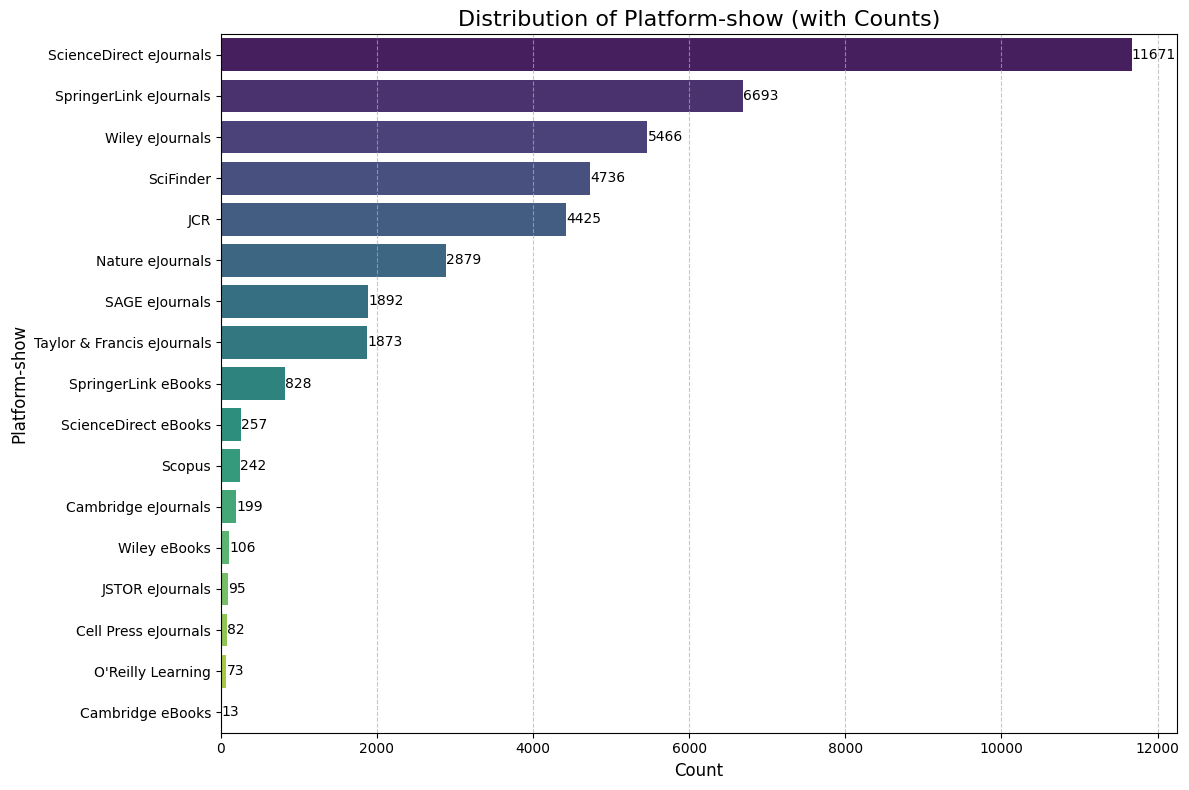

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability
plt.figure(figsize=(12, 8))

# Create the count plot
ax = sns.countplot(data=df, y='Platform-show', order=df['Platform-show'].value_counts().index, palette='viridis')

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

# Set plot title and labels
plt.title('Distribution of Platform-show (with Counts)', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Platform-show', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [17]:
print(f"Original df shape: {df.shape}")

# Separate DataFrames for ScienceDirect eJournals and Cell Press eJournals
sd_ejournal_df = df[df['Platform-show'] == 'ScienceDirect eJournals'].copy()
cell_press_ejournal_df = df[df['Platform-show'] == 'Cell Press eJournals'].copy()

print(f"\nShape of ScienceDirect eJournals: {sd_ejournal_df.shape}")
print(f"Shape of Cell Press eJournals: {cell_press_ejournal_df.shape}")

# Get unique titles from both DataFrames, handling potential NaN values
sd_titles = sd_ejournal_df['title'].dropna().unique()
cell_press_titles = cell_press_ejournal_df['title'].dropna().unique()

# Find titles that are common to both
common_titles = pd.Series(sd_titles)[pd.Series(sd_titles).isin(cell_press_titles)].tolist()

print(f"\nNumber of common titles found: {len(common_titles)}")
if len(common_titles) > 0:
    print("Sample of common titles:")
    display(pd.Series(common_titles).head())
else:
    print("No common titles found between ScienceDirect eJournals and Cell Press eJournals.")

# Filter out records from sd_ejournal_df that have titles present in common_titles
sd_ejournal_df_filtered = sd_ejournal_df[~sd_ejournal_df['title'].isin(common_titles)]

print(f"\nNumber of ScienceDirect eJournals records removed: {sd_ejournal_df.shape[0] - sd_ejournal_df_filtered.shape[0]}")

# Combine the filtered ScienceDirect eJournals with Cell Press eJournals and other platforms
other_platforms_df = df[~df['Platform-show'].isin(['ScienceDirect eJournals', 'Cell Press eJournals'])]

# Reconstruct the main DataFrame
df = pd.concat([sd_ejournal_df_filtered, cell_press_ejournal_df, other_platforms_df])

print(f"\nNew df shape after filtering: {df.shape}")
print("First 5 rows of the updated df:")
display(df.head())

Original df shape: (41530, 36)

Shape of ScienceDirect eJournals: (11671, 36)
Shape of Cell Press eJournals: (82, 36)

Number of common titles found: 1
Sample of common titles:


,0
0,Modeling Steatohepatitis in Humans with Plurip...



Number of ScienceDirect eJournals records removed: 10

New df shape after filtering: (41520, 36)
First 5 rows of the updated df:


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url,Platform-show
1,2026-07-31T17:01:01+00:00,2026-07-31,Thaneeya.nan,Science Direct,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,...,,Rubicon siRNA-encapsulated liver-targeting nan...,journal-article,,TH,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
23,2026-07-31T17:29:36+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,...,,Bronchiectasis Revisited: Imaging-Based Patter...,journal-article,,TH,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
24,2026-07-31T17:29:39+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,...,,Bronchiectasis Revisited: Imaging-Based Patter...,journal-article,,TH,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
27,2026-07-31T17:30:45+00:00,2026-07-31,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,HTML,0960-8524,0960-8524,09608524,...,,Efficient catalytic system for the conversion ...,journal-article,,TH,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
30,2026-07-31T17:32:41+00:00,2026-07-31,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,PDF,0960-8524,0960-8524,09608524,...,,Efficient catalytic system for the conversion ...,journal-article,,TH,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals


In [18]:
output_file_path_xlsx = '/content/drive/MyDrive/EZproxyData/clean_ezpaarse_output.xlsx'

try:
    df.to_excel(output_file_path_xlsx, index=False)
    print(f"Successfully saved the clean DataFrame to {output_file_path_xlsx}")
except Exception as e:
    print(f"Error saving the DataFrame to Excel: {e}")
    print("Please ensure Google Drive is mounted and the path is accessible.")

Successfully saved the clean DataFrame to /content/drive/MyDrive/EZproxyData/clean_ezpaarse_output.xlsx


In [19]:
import shutil
import os

source_csv_path = '/content/ezpaarse_output.csv'
destination_dir = '/content/drive/MyDrive/EZproxyData/'
destination_csv_path = os.path.join(destination_dir, 'ezpaarse_output.csv')

# Ensure the destination directory exists
os.makedirs(destination_dir, exist_ok=True)

try:
    shutil.copy(source_csv_path, destination_csv_path)
    print(f"Successfully copied '{source_csv_path}' to '{destination_csv_path}'")
except FileNotFoundError:
    print(f"Error: Source file '{source_csv_path}' not found.")
except Exception as e:
    print(f"Error copying file: {e}")

Successfully copied '/content/ezpaarse_output.csv' to '/content/drive/MyDrive/EZproxyData/ezpaarse_output.csv'


In [20]:
import pandas as pd

file_path = '/content/drive/MyDrive/EZproxyData/EZproxy-username-2026 - check.xlsx'
user_df = pd.read_excel(file_path)

print("ตัวอย่าง 'ID and Username' ที่มี '@mahidol.ac.th' ก่อนการล้าง:")
# Convert to string to avoid errors with non-string types, then check for substring
users_with_mahidol_email = user_df[user_df['ID and Username'].astype(str).str.contains('@mahidol.ac.th', na=False)].copy()
display(users_with_mahidol_email[['ID and Username']].head())

# Remove '@mahidol.ac.th' from 'ID and Username' column if it exists
user_df['ID and Username'] = user_df['ID and Username'].astype(str).str.replace('@mahidol.ac.th', '', regex=False)

# Rename 'ID and Username' column to 'username'
user_df.rename(columns={'ID and Username': 'username'}, inplace=True)

# Convert 'username' column to lowercase
user_df['username'] = user_df['username'].str.lower()

print("\nData loaded successfully into DataFrame 'user_df' (หลังการล้างและเปลี่ยนชื่อคอลัมน์)...ไปสู่ตัวพิมพ์เล็กแล้ว")
display(user_df.head())

ตัวอย่าง 'ID and Username' ที่มี '@mahidol.ac.th' ก่อนการล้าง:


,ID and Username



Data loaded successfully into DataFrame 'user_df' (หลังการล้างและเปลี่ยนชื่อคอลัมน์)...ไปสู่ตัวพิมพ์เล็กแล้ว


,username,Status,Faculty,Program,Name,Educational Status
0,abhisit.bha,บุคลากรมหาวิทยาลัย,คณะสิ่งแวดล้อมและทรัพยากรศาสตร์,NaN,อภิสิทธิ์ ภาสดา,NaN
1,abigail.cha,บุคลากรมหาวิทยาลัย,คณะเวชศาสตร์เขตร้อน,NaN,Abigail Chan,NaN
2,achala.pra,บุคลากรมหาวิทยาลัย,คณะเภสัชศาสตร์,NaN,อจลา ประชาญสิทธิ์,NaN
3,achara.ton,บุคลากรมหาวิทยาลัย,คณะแพทยศาสตร์โรงพยาบาลรามาธิบดี,NaN,อัจฉรา ทองภู,NaN
4,achiraya.tey,บุคลากรมหาวิทยาลัย,คณะแพทยศาสตร์ศิริราชพยาบาล,NaN,อชิรญา เตยะธิติ,NaN


In [22]:
import pandas as pd

# Merge df and user_df on 'login' and 'username' respectively
merged_df = pd.merge(df, user_df, left_on='login', right_on='username', how='left')

# Remove 'username' column from merged_df as it is redundant after the merge with 'login'
if 'username' in merged_df.columns:
    merged_df = merged_df.drop(columns=['username'])

print("DataFrame `merged_df` created successfully after joining `df` and `user_df`.")
print(f"Shape of merged_df: {merged_df.shape}")
display(merged_df.head())

DataFrame `merged_df` created successfully after joining `df` and `user_df`.
Shape of merged_df: (41520, 41)


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,geoip-latitude,geoip-longitude,host,url,Platform-show,Status,Faculty,Program,Name,Educational Status
0,2026-07-31T17:01:01+00:00,2026-07-31,Thaneeya.nan,Science Direct,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,...,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN
1,2026-07-31T17:29:36+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
2,2026-07-31T17:29:39+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
3,2026-07-31T17:30:45+00:00,2026-07-31,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,HTML,0960-8524,0960-8524,09608524,...,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN
4,2026-07-31T17:32:41+00:00,2026-07-31,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,PDF,0960-8524,0960-8524,09608524,...,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN


In [26]:
list_copay_db = ['Cell Press eJournals', 'ScienceDirect eJournals', 'SpringerLink eJournals', 'Wiley eJournals', 'Micromedex', "O'Reilly Learning"]

In [27]:
import pandas as pd

copay_df = merged_df[merged_df['Platform-show'].isin(list_copay_db)].copy()

print(f"Filtered DataFrame 'copay_df' created. It now contains {copay_df.shape[0]} rows.")
display(copay_df.head())

Filtered DataFrame 'copay_df' created. It now contains 23975 rows.


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,geoip-latitude,geoip-longitude,host,url,Platform-show,Status,Faculty,Program,Name,Educational Status
0,2026-07-31T17:01:01+00:00,2026-07-31,Thaneeya.nan,Science Direct,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,...,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN
1,2026-07-31T17:29:36+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
2,2026-07-31T17:29:39+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
3,2026-07-31T17:30:45+00:00,2026-07-31,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,HTML,0960-8524,0960-8524,09608524,...,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN
4,2026-07-31T17:32:41+00:00,2026-07-31,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,PDF,0960-8524,0960-8524,09608524,...,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN


Font TH Sarabun New loaded successfully.


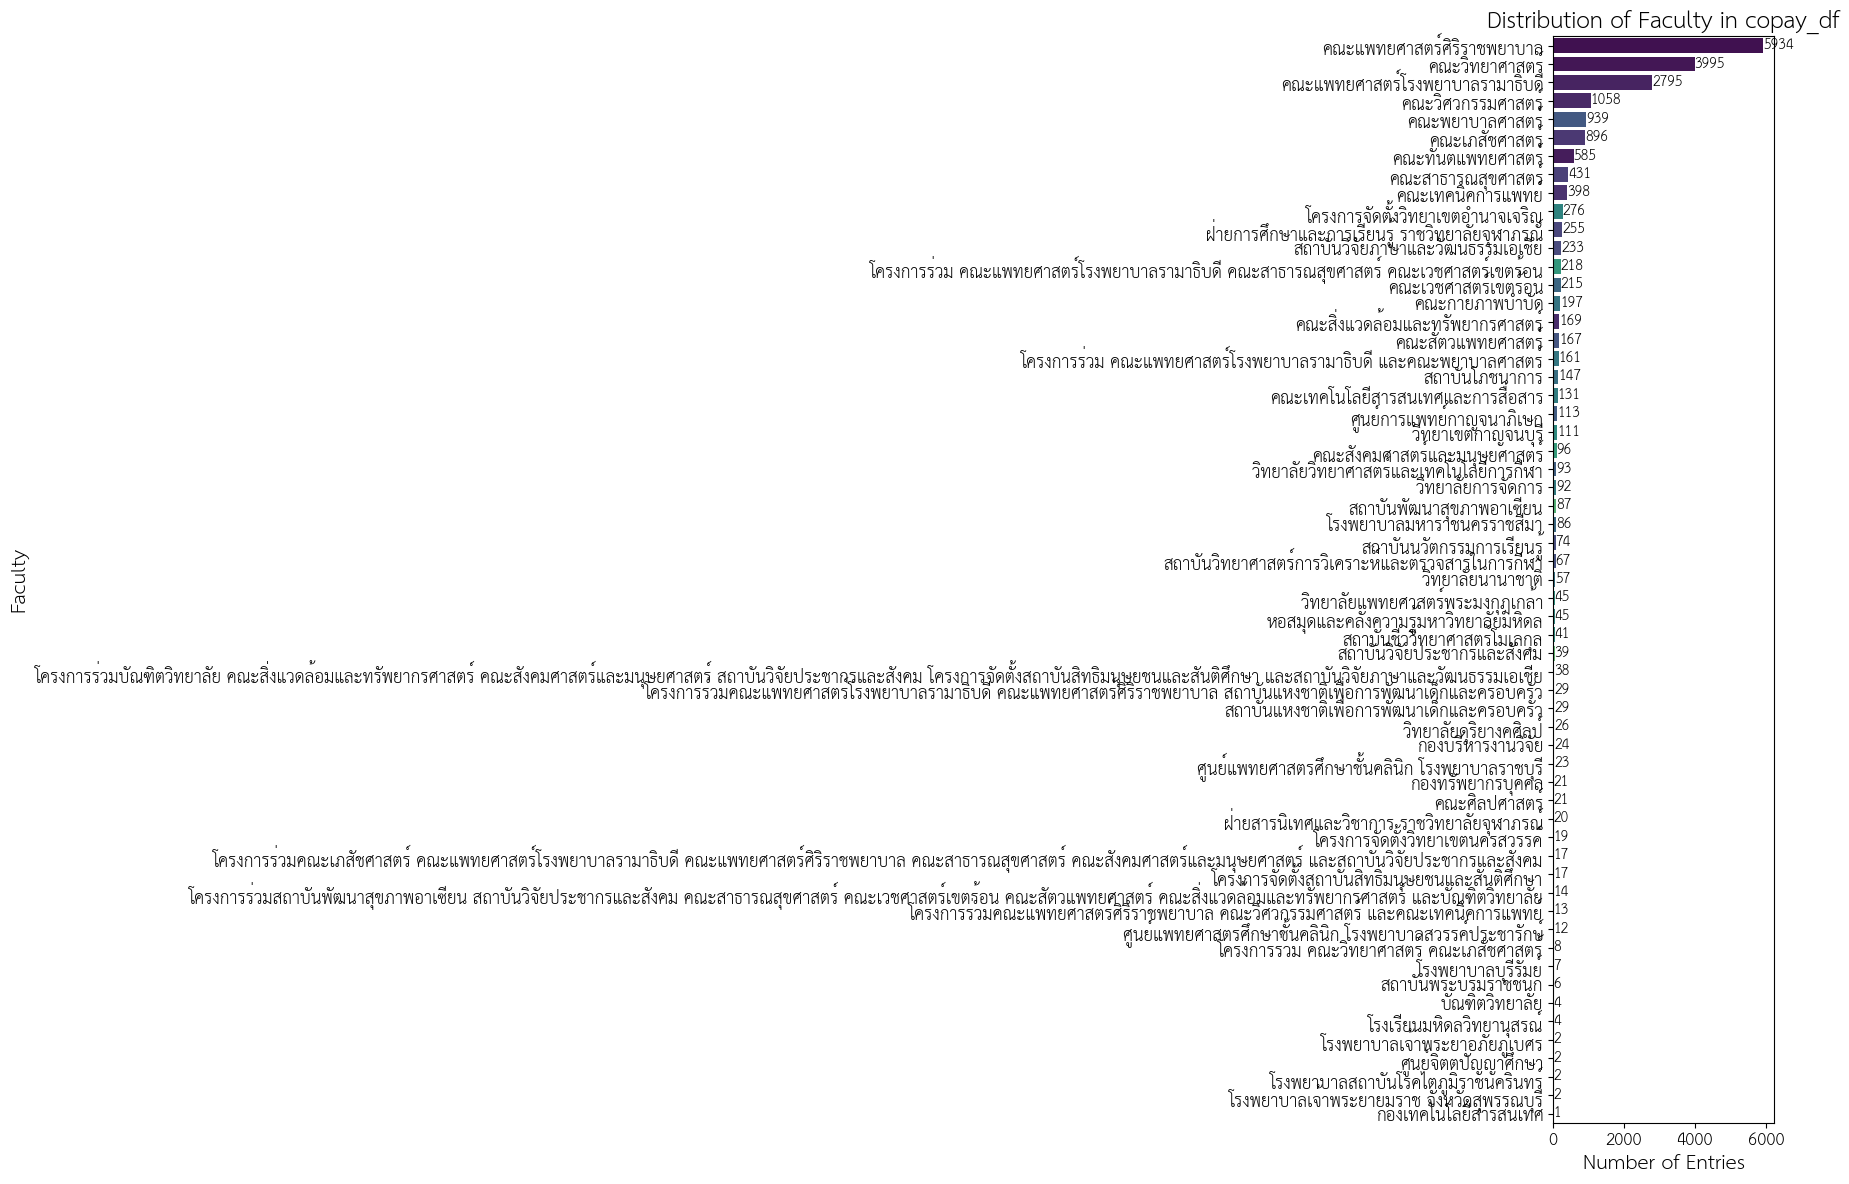

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import urllib.request
import os

# ดาวน์โหลดฟอนต์ TH Sarabun New โดยตรงเพื่อความแน่นอน
font_path = 'THSarabunNew.ttf'
if not os.path.exists(font_path):
    print("Downloading TH Sarabun New font...")
    urllib.request.urlretrieve('https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf', font_path)

# เพิ่มฟอนต์ลงในระบบของ Matplotlib
try:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'TH Sarabun New'
    plt.rcParams['font.size'] = 12 # ปรับขนาดฟอนต์ให้อ่านง่ายขึ้น
    print("Font TH Sarabun New loaded successfully.")
except Exception as e:
    print(f"Error loading font: {e}")

plt.rcParams['axes.unicode_minus'] = False

if 'Faculty' in copay_df.columns:
    # ขยายขนาดกราฟ (กว้าง 18, สูง 12) เพื่อรองรับชื่อคณะที่ยาวมาก
    plt.figure(figsize=(18, 12))

    ax = sns.countplot(y='Faculty', data=copay_df, order=copay_df['Faculty'].value_counts().index, palette='viridis', hue='Faculty', legend=False)

    # Add numbers on the bars with explicit fontsize
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

    plt.title('Distribution of Faculty in copay_df', fontsize=16)
    plt.xlabel('Number of Entries', fontsize=14)
    plt.ylabel('Faculty', fontsize=14)

    # ใช้ tight_layout เพื่อให้จัดการขอบและ margin ให้พอดี
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Faculty' not found in copay_df. Please ensure the column exists and is spelled correctly.")

In [32]:
import pandas as pd

faculties_to_filter = [
    'โครงการจัดตั้งวิทยาเขตนครสวรรค์',
    'โครงการจัดตั้งวิทยาเขตอำนาจเจริญ',
    'โครงการจัดตั้งศูนย์พัฒนาอุตสาหกรรมชีวภาพ มหาวิทยาลัยมหิดล',
    'โครงการจัดตั้งสถาบันสิทธิมนุษยชนและสันติศึกษา',
    'คณะเทคโนโลยีสารสนเทศและการสื่อสาร',
    'คณะเทคนิคการแพทย์',
    'คณะเภสัชศาสตร์',
    'คณะเวชศาสตร์เขตร้อน',
    'คณะแพทยศาสตร์โรงพยาบาลรามาธิบดี',
    'คณะแพทยศาสตร์ศิริราชพยาบาล',
    'คณะกายภาพบำบัด',
    'คณะทันตแพทยศาสตร์',
    'คณะพยาบาลศาสตร์',
    'คณะวิทยาศาสตร์',
    'คณะวิศวกรรมศาสตร์',
    'คณะศิลปศาสตร์',
    'คณะสังคมศาสตร์และมนุษยศาสตร์',
    'คณะสัตวแพทยศาสตร์',
    'คณะสาธารณสุขศาสตร์',
    'คณะสิ่งแวดล้อมและทรัพยากรศาสตร์',
    'วิทยาเขตกาญจนบุรี',
    'วิทยาลัยการจัดการ',
    'วิทยาลัยดุริยางคศิลป์',
    'วิทยาลัยนานาชาติ',
    'วิทยาลัยวิทยาศาสตร์และเทคโนโลยีการกีฬา',
    'วิทยาลัยศาสนศึกษา',
    'ศูนย์จิตตปัญญาศึกษา',
    'ศูนย์สัตว์ทดลองแห่งชาติ',
    'สถาบันแห่งชาติเพื่อการพัฒนาเด็กและครอบครัว',
    'สถาบันโภชนาการ',
    'สถาบันชีววิทยาศาสตร์โมเลกุล',
    'สถาบันนวัตกรรมการเรียนรู้',
    'สถาบันบริหารจัดการเทคโนโลยีและนวัตกรรม',
    'สถาบันพัฒนาสุขภาพอาเซียน',
    'สถาบันวิจัยประชากรและสังคม',
    'สถาบันวิจัยภาษาและวัฒนธรรมเอเชีย',
    'สถาบันวิทยาศาสตร์การวิเคราะห์และตรวจสารในการกีฬา'
]

copay_filtered_df = copay_df[copay_df['Faculty'].isin(faculties_to_filter)].copy()

print(f"Filtered DataFrame 'copay_filtered_df' created. It now contains {copay_filtered_df.shape[0]} rows.")
display(copay_filtered_df.head())

Filtered DataFrame 'copay_filtered_df' created. It now contains 19437 rows.


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,geoip-latitude,geoip-longitude,host,url,Platform-show,Status,Faculty,Program,Name,Educational Status
1,2026-07-31T17:29:36+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
2,2026-07-31T17:29:39+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
5,2026-07-31T17:41:35+00:00,2026-07-31,g6737504,Science Direct,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
6,2026-07-31T17:44:06+00:00,2026-07-31,g6636296,Science Direct,Elsevier,ARTICLE,HTML,1368-7646,1368-7646,13687646,...,13.7442,100.4608,27.55.96.246,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ปริญญาโท,คณะวิทยาศาสตร์,วิทยาศาสตรมหาบัณฑิต สาขาวิชาพยาธิชีววิทยา (หลั...,ฉัตรสุดา สุรชัยจรินทร์,กำลังศึกษาอยู่
7,2026-07-31T18:28:19+00:00,2026-07-31,u6629015,Science Direct,Elsevier,ARTICLE,HTML,0003-9969,0003-9969,00039969,...,13.7512,100.5172,49.49.251.234,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ปริญญาตรี,คณะทันตแพทยศาสตร์,ทันตแพทยศาสตรบัณฑิต (หลักสูตรนานาชาติ),ภทรธร ไตรสิกขาธรรม,กำลังศึกษาอยู่


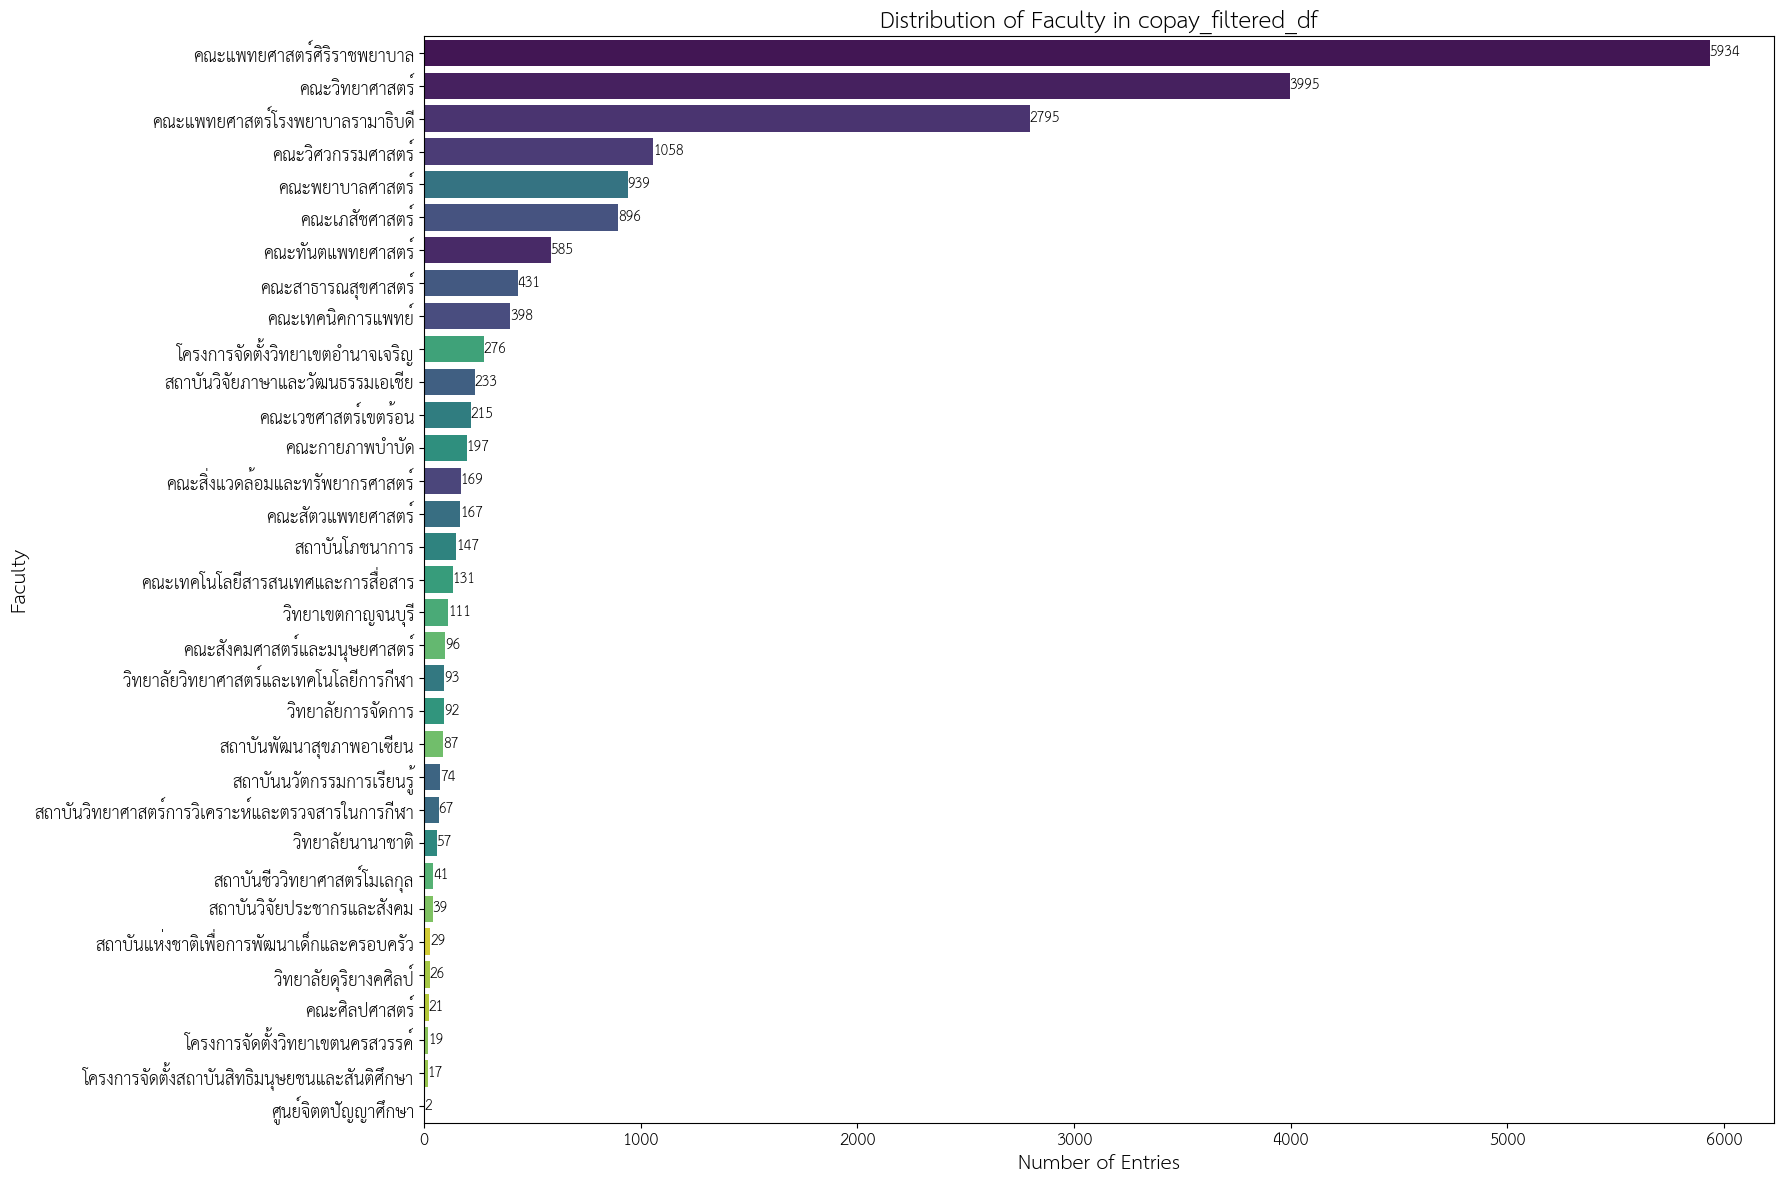

In [33]:
if 'Faculty' in copay_df.columns:
    # ขยายขนาดกราฟ (กว้าง 18, สูง 12) เพื่อรองรับชื่อคณะที่ยาวมาก
    plt.figure(figsize=(18, 12))

    ax = sns.countplot(y='Faculty', data=copay_filtered_df, order=copay_filtered_df['Faculty'].value_counts().index, palette='viridis', hue='Faculty', legend=False)

    # Add numbers on the bars with explicit fontsize
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

    plt.title('Distribution of Faculty in copay_filtered_df', fontsize=16)
    plt.xlabel('Number of Entries', fontsize=14)
    plt.ylabel('Faculty', fontsize=14)

    # ใช้ tight_layout เพื่อให้จัดการขอบและ margin ให้พอดี
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Faculty' not found in copay_filtered_df. Please ensure the column exists and is spelled correctly.")

In [35]:
import pandas as pd

# กำหนดงบประมาณจำลอง (Dummy Budget) สำหรับแต่ละฐานข้อมูลใน list_copay_db
# ตัวเลขเป็นค่าสมมติ (บาท)
dummy_budget_data = {
    'Cell Press eJournals': 2000000,
    'ScienceDirect eJournals': 27000000,
    'SpringerLink eJournals': 9000000,
    'Wiley eJournals': 25000000,
    'Micromedex': 1800000,
    "O'Reilly Learning": 900000
}

# ตรวจสอบว่าคีย์ทั้งหมดตรงกับค่าใน list_copay_db
# สร้าง DataFrame เพื่อความสวยงามและการนำไปจัดทำรายงานต่อ
budget_df = pd.DataFrame(list(dummy_budget_data.items()), columns=['Platform-show', 'Budget_THB'])

print("✅ สร้างข้อมูลงบประมาณจำลอง (budget_df) เรียบร้อยแล้ว:")
display(budget_df)

✅ สร้างข้อมูลงบประมาณจำลอง (budget_df) เรียบร้อยแล้ว:


,Platform-show,Budget_THB
0,Cell Press eJournals,2000000
1,ScienceDirect eJournals,27000000
2,SpringerLink eJournals,9000000
3,Wiley eJournals,25000000
4,Micromedex,1800000
5,O'Reilly Learning,900000


In [36]:
import pandas as pd

# 1. Calculate monthly usage for each platform from copay_df
monthly_usage = copay_df['Platform-show'].value_counts().reset_index()
monthly_usage.columns = ['Platform-show', 'Monthly_Usage']

# 2. Estimate annual usage (assuming 12 months for annual budget)
monthly_usage['Estimated_Annual_Usage'] = monthly_usage['Monthly_Usage'] * 12

# 3. Merge with budget_df to get the annual budget for each platform
#    Ensure that 'Platform-show' column in budget_df is clean (no extra spaces)
budget_df['Platform-show'] = budget_df['Platform-show'].str.strip()

cost_per_use_df = pd.merge(budget_df, monthly_usage, on='Platform-show', how='left')

# Handle platforms that might not have usage data in copay_df (filling with 0 for usage)
cost_per_use_df['Monthly_Usage'] = cost_per_use_df['Monthly_Usage'].fillna(0).astype(int)
cost_per_use_df['Estimated_Annual_Usage'] = cost_per_use_df['Estimated_Annual_Usage'].fillna(0).astype(int)

# 4. Calculate Cost Per Use (Budget_THB / Estimated_Annual_Usage)
#    Handle potential division by zero for platforms with no estimated annual usage
cost_per_use_df['Cost_Per_Use_THB'] = cost_per_use_df.apply(
    lambda row: row['Budget_THB'] / row['Estimated_Annual_Usage'] if row['Estimated_Annual_Usage'] > 0 else float('inf'),
    axis=1
)

print("Cost per Use (THB) by Platform:")
display(cost_per_use_df.sort_values(by='Cost_Per_Use_THB', ascending=False))

Cost per Use (THB) by Platform:


,Platform-show,Budget_THB,Monthly_Usage,Estimated_Annual_Usage,Cost_Per_Use_THB
4,Micromedex,1800000,0,0,inf
0,Cell Press eJournals,2000000,82,984,2032.520325
5,O'Reilly Learning,900000,73,876,1027.397260
3,Wiley eJournals,25000000,5466,65592,381.144042
1,ScienceDirect eJournals,27000000,11661,139932,192.950862
2,SpringerLink eJournals,9000000,6693,80316,112.057373


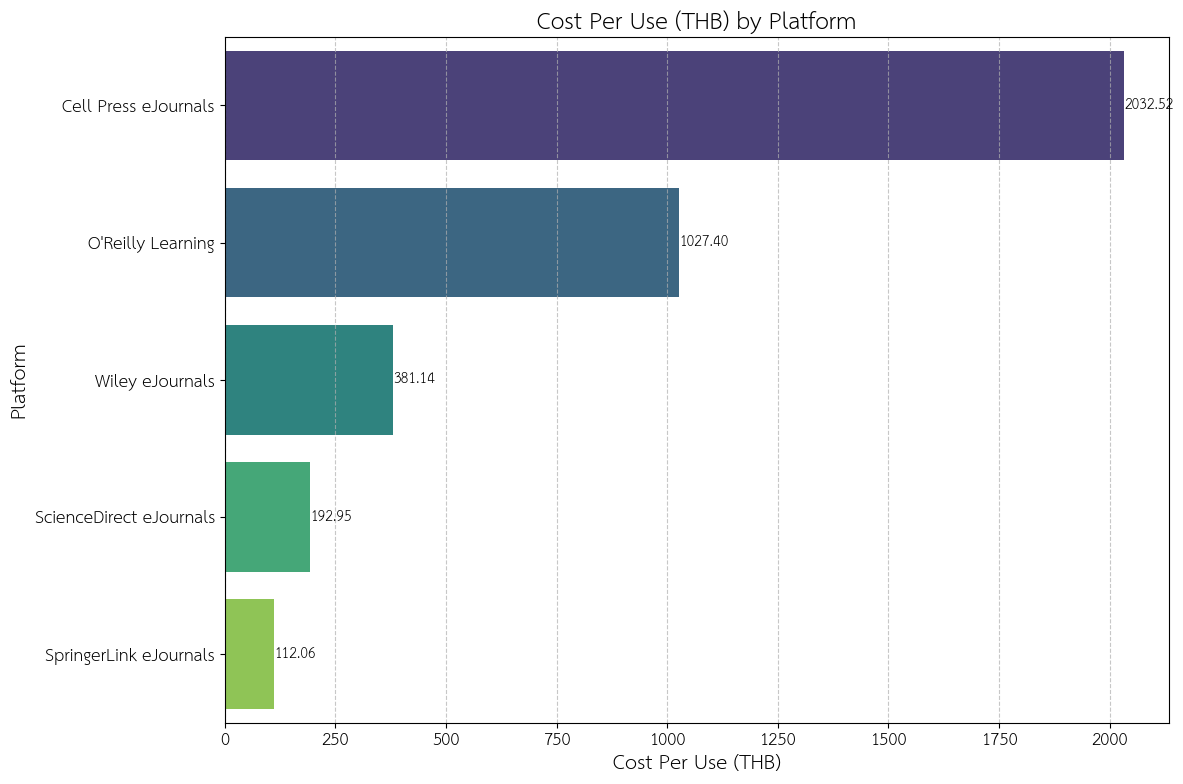

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a copy to avoid modifying the original DataFrame unintentionally
plot_df = cost_per_use_df.copy()

# Replace inf values with NaN for plotting purposes and then drop them
plot_df['Cost_Per_Use_THB'] = plot_df['Cost_Per_Use_THB'].replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=['Cost_Per_Use_THB'])

# Sort by Cost_Per_Use_THB in descending order for better visualization
plot_df = plot_df.sort_values(by='Cost_Per_Use_THB', ascending=False)

plt.figure(figsize=(12, 8))

# Create the bar plot, addressing the FutureWarning by explicitly setting hue and legend
ax = sns.barplot(
    x='Cost_Per_Use_THB',
    y='Platform-show',
    data=plot_df,
    palette='viridis',
    hue='Platform-show',
    legend=False
)

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

plt.title('Cost Per Use (THB) by Platform', fontsize=16)
plt.xlabel('Cost Per Use (THB)', fontsize=14)
plt.ylabel('Platform', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()